In [12]:
# Imports and setup
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Plot settings
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 11

In [13]:
log_dir = Path("logs/2026-03-09/01-37-11/lightning_logs/version_0")

event_acc = EventAccumulator(str(log_dir))
event_acc.Reload()

tags = event_acc.Tags()
tags

{'images': [],
 'audio': [],
 'histograms': [],
 'scalars': ['hp_metric',
  'lr-Adam',
  'train/loss',
  'train/skipped_empty_targets',
  'epoch',
  'val/loss',
  'val/skipped_empty_targets',
  'val/CER',
  'val/IER',
  'val/DER',
  'val/SER',
  'train/CER',
  'train/IER',
  'train/DER',
  'train/SER',
  'test/loss',
  'test/skipped_empty_targets',
  'test/CER',
  'test/IER',
  'test/DER',
  'test/SER'],
 'distributions': [],
 'tensors': [],
 'graph': False,
 'meta_graph': False,
 'run_metadata': []}

In [14]:
# Helper function to convert TensorBoard scalars into a DataFrame
def scalar_to_df(event_acc, tag):
    events = event_acc.Scalars(tag)
    return pd.DataFrame({
        "step": [e.step for e in events],
        "value": [e.value for e in events],
        "wall_time": [e.wall_time for e in events],
    })

In [15]:
# Load the main metrics
available_scalars = tags.get("scalars", [])
print("Available scalar metrics:")
for s in available_scalars:
    print("-", s)

Available scalar metrics:
- hp_metric
- lr-Adam
- train/loss
- train/skipped_empty_targets
- epoch
- val/loss
- val/skipped_empty_targets
- val/CER
- val/IER
- val/DER
- val/SER
- train/CER
- train/IER
- train/DER
- train/SER
- test/loss
- test/skipped_empty_targets
- test/CER
- test/IER
- test/DER
- test/SER


In [16]:
# Load the important metrics
val_cer_df = scalar_to_df(event_acc, "val/CER")
val_loss_df = scalar_to_df(event_acc, "val/loss")

# Try both possible training loss names, depending on how Lightning logged them
train_loss_tag = None
for candidate in ["train/loss", "train/loss_epoch"]:
    if candidate in available_scalars:
        train_loss_tag = candidate
        break

if train_loss_tag is not None:
    train_loss_df = scalar_to_df(event_acc, train_loss_tag)
else:
    train_loss_df = None
    print("No train loss scalar found.")

In [17]:
# Add an epoch axis
val_cer_df["epoch_idx"] = range(len(val_cer_df))
val_loss_df["epoch_idx"] = range(len(val_loss_df))

if train_loss_df is not None:
    train_loss_df["point_idx"] = range(len(train_loss_df))

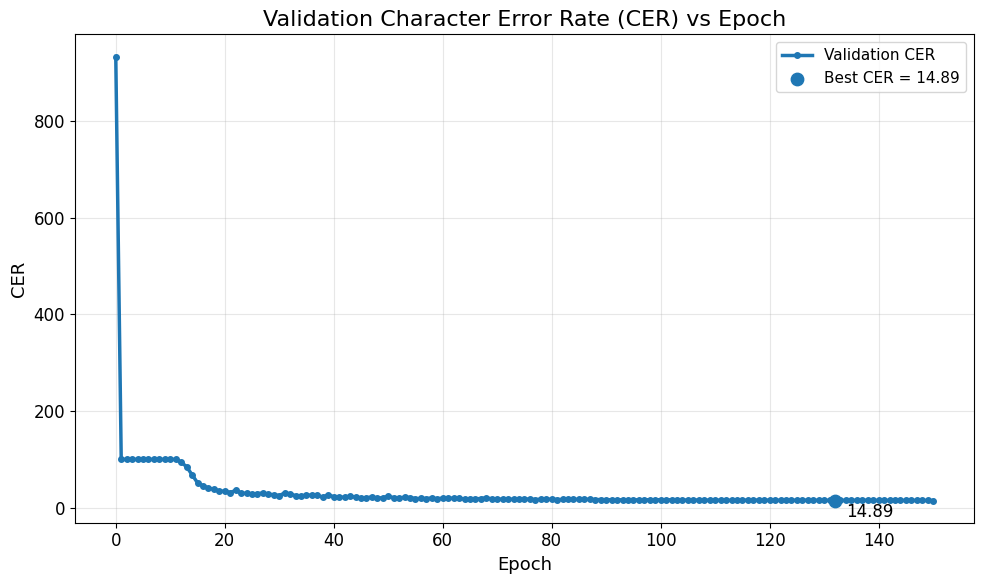

In [18]:
# Validation CER over epochs
fig, ax = plt.subplots()

ax.plot(
    val_cer_df["epoch_idx"],
    val_cer_df["value"],
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Validation CER"
)

best_idx = val_cer_df["value"].idxmin()
best_epoch = val_cer_df.loc[best_idx, "epoch_idx"]
best_cer = val_cer_df.loc[best_idx, "value"]

ax.scatter(best_epoch, best_cer, s=80, zorder=3, label=f"Best CER = {best_cer:.2f}")
ax.annotate(
    f"{best_cer:.2f}",
    (best_epoch, best_cer),
    textcoords="offset points",
    xytext=(8, -12)
)

ax.set_title("Validation Character Error Rate (CER) vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("CER")
ax.legend()
plt.tight_layout()
plt.show()

**Validation CER vs Epoch**

The validation character error rate (CER) decreases sharply in the early epochs, indicating that the CNN layers quickly learn useful local features from the EMG signals. As training progresses, the BiLSTM layers capture temporal dependencies across the signal sequence, allowing the model to better predict character sequences. The CER gradually stabilizes and reaches a best validation CER of 14.89, showing that the CNN–BiLSTM architecture effectively learns both spatial and temporal patterns in the EMG data.

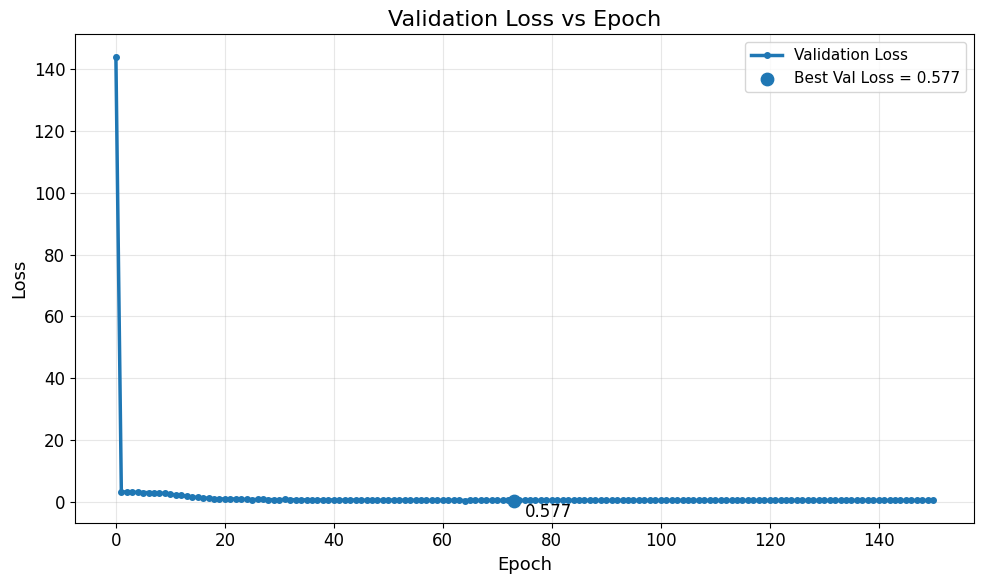

In [19]:
# Validation loss over epochs
fig, ax = plt.subplots()

ax.plot(
    val_loss_df["epoch_idx"],
    val_loss_df["value"],
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Validation Loss"
)

best_idx = val_loss_df["value"].idxmin()
best_epoch = val_loss_df.loc[best_idx, "epoch_idx"]
best_loss = val_loss_df.loc[best_idx, "value"]

ax.scatter(best_epoch, best_loss, s=80, zorder=3, label=f"Best Val Loss = {best_loss:.3f}")
ax.annotate(
    f"{best_loss:.3f}",
    (best_epoch, best_loss),
    textcoords="offset points",
    xytext=(8, -12)
)

ax.set_title("Validation Loss vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

**Validation Loss vs Epoch**

The validation loss follows a similar decreasing trend, dropping rapidly during the initial epochs and then stabilizing. This behavior suggests that the CTC loss successfully learns the alignment between the EMG signal sequences and the target character sequences without requiring explicit segmentation. The lowest validation loss of 0.577 indicates that the model has learned a stable mapping from EMG inputs to text outputs.

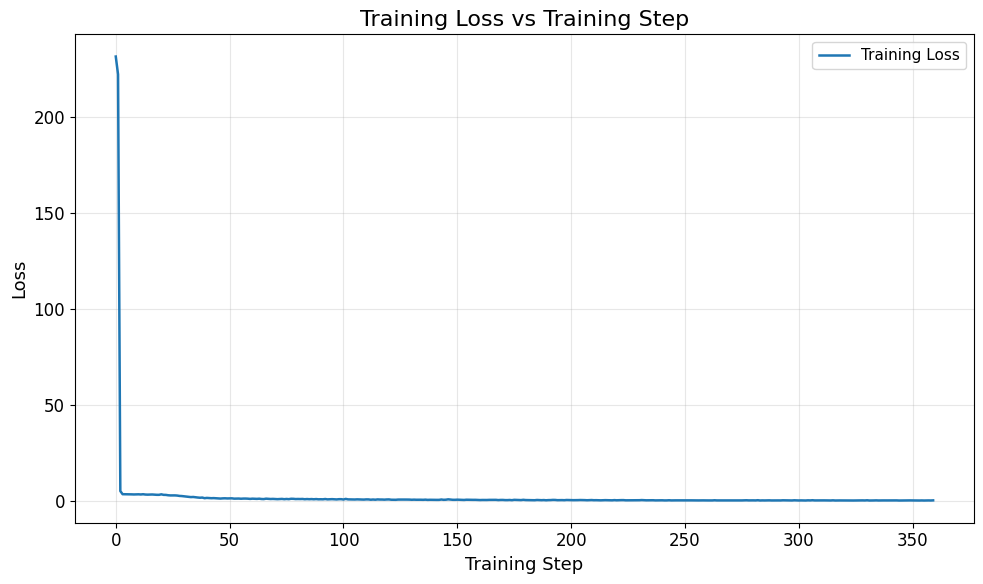

In [20]:
# Training loss over training steps
if train_loss_df is not None:
    fig, ax = plt.subplots()

    ax.plot(
        train_loss_df["point_idx"],
        train_loss_df["value"],
        linewidth=1.8,
        label="Training Loss"
    )

    ax.set_title("Training Loss vs Training Step")
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Training loss not found in TensorBoard scalars.")

**Training Loss vs Training Step**

The training loss decreases significantly during the early training steps as the CNN layers learn feature representations and the BiLSTM layers begin modeling sequential dependencies. The loss gradually approaches a stable value, suggesting that the optimization process is effectively minimizing the CTC objective.

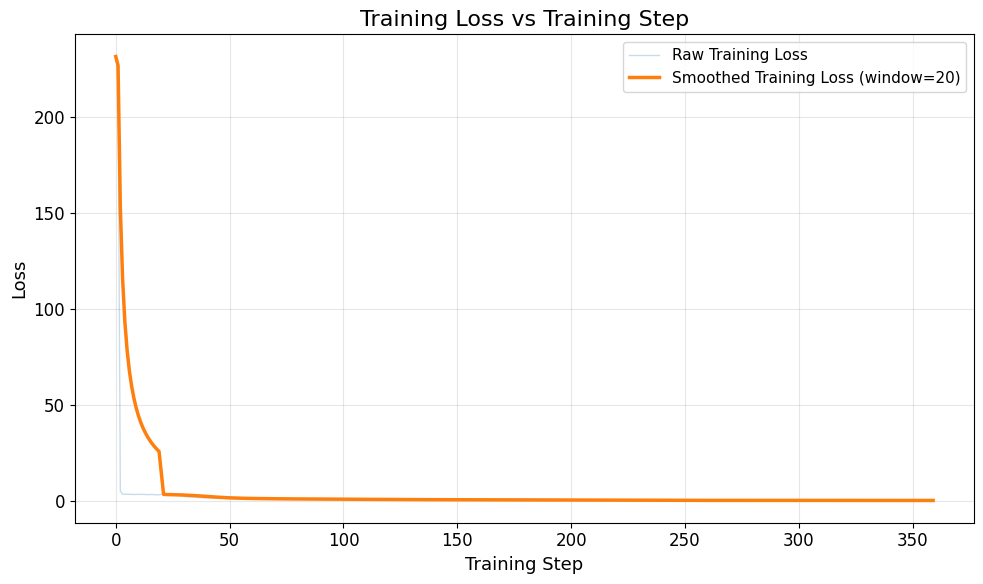

In [21]:
# Smoothed training loss plot for cleaner visualization
if train_loss_df is not None:
    smooth_window = 20
    train_loss_df["smoothed"] = train_loss_df["value"].rolling(smooth_window, min_periods=1).mean()

    fig, ax = plt.subplots()

    ax.plot(
        train_loss_df["point_idx"],
        train_loss_df["value"],
        alpha=0.25,
        linewidth=1,
        label="Raw Training Loss"
    )
    ax.plot(
        train_loss_df["point_idx"],
        train_loss_df["smoothed"],
        linewidth=2.5,
        label=f"Smoothed Training Loss (window={smooth_window})"
    )

    ax.set_title("Training Loss vs Training Step")
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()

**Smoothed Training Loss vs Training Step**

The smoothed training loss highlights a consistent downward trend, indicating stable training. The absence of large fluctuations suggests that the CNN feature extractor and BiLSTM sequence model are jointly learning robust representations, leading to steady convergence of the CTC-based decoding model.

In [22]:
# Summary table
summary_df = pd.DataFrame({
    "Metric": [
        "Best Validation CER",
        "Final Validation Loss",
        "Test CER",
        "Test Loss",
        "Model Parameters"
    ],
    "Value": [
        round(val_cer_df["value"].min(), 3),
        round(val_loss_df["value"].iloc[-1], 3),
        17.951,   # from your test output
        0.719,    # from your test output
        "3.5M"
    ]
})

summary_df

,Metric,Value
0,Best Validation CER,14.887
1,Final Validation Loss,0.592
2,Test CER,17.951
3,Test Loss,0.719
4,Model Parameters,3.5M


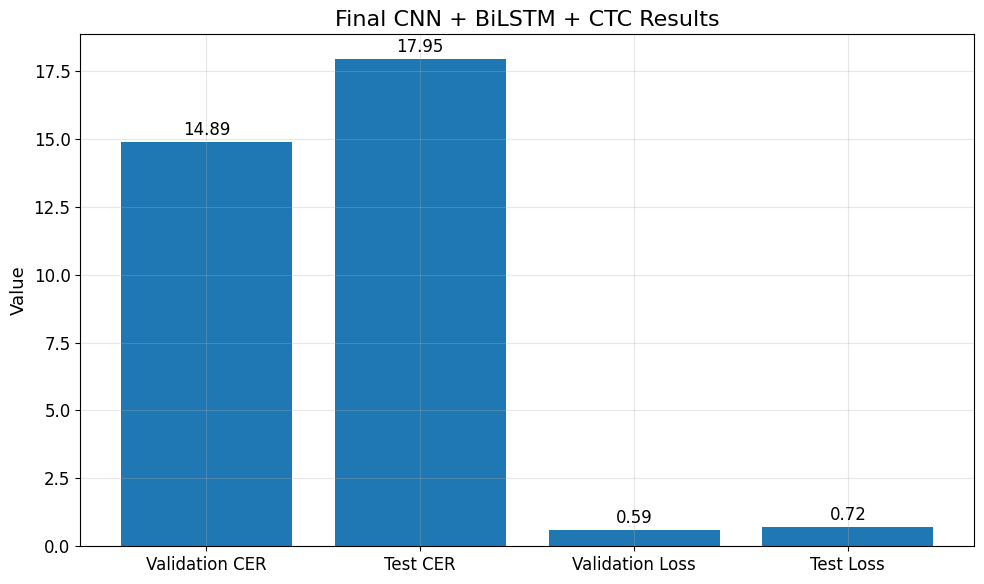

In [23]:
final_results = pd.DataFrame({
    "Metric": ["Validation CER", "Test CER", "Validation Loss", "Test Loss"],
    "Value": [14.887, 17.951, 0.592, 0.719]
})

fig, ax = plt.subplots()

bars = ax.bar(final_results["Metric"], final_results["Value"])

ax.set_title("Final CNN + BiLSTM + CTC Results")
ax.set_ylabel("Value")

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [6]:
!ls logs/2026-03-09/01-37-11/lightning_logs/version_0

events.out.tfevents.1773020238.ece-vm1	events.out.tfevents.1773118350.ece-vm1
events.out.tfevents.1773118344.ece-vm1	hparams.yaml


In [11]:
!pwd

/home/anushkanayak15/semg-keystroke-decoding
